<img src="assets/DemoSlidesForExport_0.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star Initialization</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
C-Star consists of python packages that are installable via <code>pip</code> — the standard Python package installer.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Carbon-accounting coastal model simulations and analysis can be run using imported python objects.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Begin by importing python package(s), and checking the environment:
</p>
</div>

In [1]:
%load_ext autoreload
%autoreload 2

from datetime import datetime
from IPython.display import Markdown, display

import cson_forge as CStar_Forge
import roms_tools as rt

env = CStar_Forge.config.get_environment_info()

# Display summary
summary = f"""
### Machine Information
- **Hostname**: `{env.hostname}`
- **System Tag**: `{env.system_tag}`
- **OS**: `{env.os_info}`

### Environment Summary
- **Python Version**: `{env.python_version}`
- **Python Executable**: `{env.python_executable}`
- **Conda/Micromamba Environment**: `{env.env_info}`
- **Kernel**: `{env.kernel_spec}`
"""

display(Markdown(summary))
print(f"C-Star imported: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")



### Machine Information
- **Hostname**: `hoatzin`
- **System Tag**: `MacOS`
- **OS**: `Darwin 25.4.0 (arm64)`

### Environment Summary
- **Python Version**: `3.13.13`
- **Python Executable**: `/Users/blsaenz/miniforge3/envs/cworthy-test/bin/python`
- **Conda/Micromamba Environment**: `cworthy-test (/Users/blsaenz/miniforge3/envs/cworthy-test)`
- **Kernel**: `unknown`


C-Star imported: 2026-05-14 06:09:14


<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Develop CDR forcing</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
A CDR intervention can be planned and built by C-star. Here we add the requirements to the CStarSpecBuilder to create modified blueprints and ROMS-MARBL input files in order to add alkalinity (at a location, details on amount): </p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Maybe details here, showing code chages.</p>
</div>

In [10]:
# make CDR forcing
start_time = datetime(2010, 1, 1)
end_time = datetime(2010, 1, 10)

times = [datetime(2010, 1, 1, 0),
           datetime(2010, 1, 2, 0),
           datetime(2010, 1, 5, 0),
          ]

volume_fluxes = [0, 100, 500] # m3/s
tracer_fluxes = {"ALK": [0.0, 60.0*10**6, 60.0*10**6]} # meq/s
tracer_concentrations = {
    "ALK": [1900.0, 2100.0, 1900.0],  # meq/m3
    "temp": 20.0,  # degrees C
    "salt": 1.0,  # psu
}

cdr_tracer_release1 = rt.TracerPerturbation(
name="release_1",
    lat=59.64,  # degree N
    lon=211.12,  # degree E
    depth=2,  # m
    hsc=500,
    vsc=300,
    times=times,
    tracer_fluxes=tracer_fluxes
)

cdr_volume_release1 = rt.VolumeRelease(
    name="v_release1",
    lat=57.88,  # degree N
    lon=360.-151.67,  # degree E
    depth=2,  # m
    times=times,
    volume_fluxes=volume_fluxes,
    tracer_concentrations=tracer_concentrations,
)

print("CDR options loaded.\n")

CDR options loaded.



<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Define model grid</h1>
    <p style="font-size: large; line-height: 1.45; margin: 0;">
Here we name and define a ROMS model grid using named parameters, grouped into 'settings' and 'boundaries'.
    <p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
These python objects will be used in the next step to establish CStarSpeBuilder, which will be used to complete C-Star setup.
    </p>
</div>

<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Define the dimensions that will build a ROMS model grid with plain-language names:
</p>

In [2]:
# Grid parameters ------------------------------------------------------------------
grid_name = "StationPapa"
grid_settings = dict[str, float](
    nx=3, #;320,              # X-direction grid cells (xi)
    ny=3, #160,              # Y-direction grid cells (eta)
    size_x=3,         # km (longitude direction at ~49N)
    size_y=3,         # km (latitude direction)
    center_lon=-145.0,   
    center_lat=50.,
    rot=0,              # rotation of grid (degrees)
    N=100,                # number of vertical levels
    #N=50,                # number of vertical levels
    theta_s=6.0,         # surface control parameter
    theta_b=3.0,         # bottom control parameter
    hc=250.0,            # critical depth
    #close_narrow_channels=True,
)
boundaries = {
        "south": False,
        "east": False,
        "north": False,
        "west": False, 
}
print("\nGrid options loaded.\n")


Grid options loaded.



<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Generate the full CDR forcing and plot:
</p>

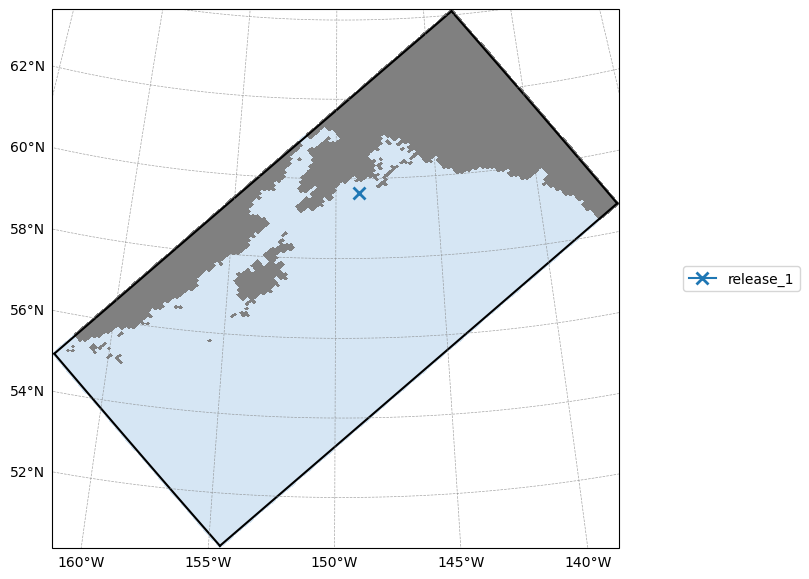

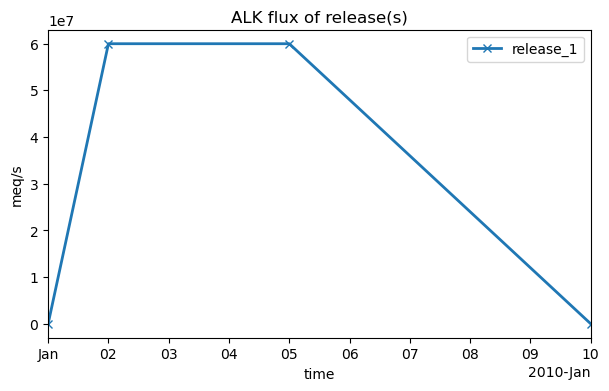

In [4]:
cdr = rt.CDRForcing(
    grid=rt.Grid(**grid_settings), # for plotting, could omit
    start_time=start_time,
    end_time=end_time,
    releases=[cdr_tracer_release1,],
)

cdr.plot_locations()
#cdr.plot_distribution("my_cdr")
cdr.plot_tracer_flux("ALK")

# Pass the cdr information as a dict, for now:
cdr_as_dict = cdr.model_dump()["CDRForcing"]

<p style="font-size: large; line-height: 1.45; margin: 0;">
Next we define a test model, using a pre-defined ROMS-MARBL model specification (a <b>model_spec</b>, which contains settings to enable ROMS-MARBL features and compilation to match your inputs and environment -- see models.yml for definition), and start and end dates.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
These changeable options are passed to the CstarSpecBuilder() object, which will find and generate the <b>forcing data</b>, and <b>C-Star blueprints</b> which will run the ROMS model and ensure <b>scientific reproducability<b>:
</p>

CstarSpecBuilder: planned NetCDF outputs
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_StationPapa_1procs/cson_roms-marbl_v0_1_StationPapa_1procs_grid.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_StationPapa_1procs/cson_roms-marbl_v0_1_StationPapa_1procs_initial_conditions.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_StationPapa_1procs/cson_roms-marbl_v0_1_StationPapa_1procs_surface-physics.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_StationPapa_1procs/cson_roms-marbl_v0_1_StationPapa_1procs_surface-bgc.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_StationPapa_1procs/cson_roms-marbl_v0_1_StationPapa_1procs_tidal.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_StationPapa_1procs/cson_roms-marbl_v0_1_StationPapa_1procs_river.nc

CstarSpecBuilder: output locations
  NetCDF files: /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_Statio

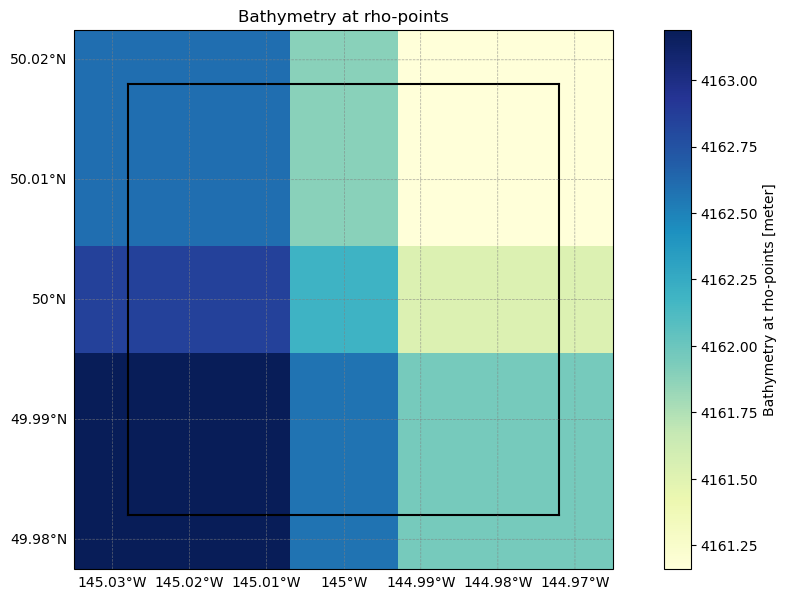

In [4]:
#Change to roms-tools grid gen, for plotting
start_time = datetime(2010, 1, 1)
end_time = datetime(2010, 1, 10)

# Model setup ------------------------------------------------------------------
model_spec = "cson_roms-marbl_v0.1"

partitioning = {
    "n_procs_x": 1, # number of partitions in xi (x) 
    "n_procs_y": 1, # number of partitions in eta (y) 
}

# Initialize CstarSpecBuilder --------------------------------------------------
ocn = CStar_Forge.CstarSpecBuilder(
    description="1D_StationPapa",
    model_name=model_spec,
    grid_name=grid_name,
    grid_kwargs=grid_settings,
    open_boundaries=boundaries,    
    start_time=start_time,
    end_time=end_time,
    partitioning=partitioning,
    #CDR_forcing=cdr_as_dict,
)

ocn.grid.plot()

Possibilities:  Change grid rotation.  

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star Forcing Data and Blueprint Generation</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
C-Star uses online, published datasets for ocean bathymetry, atmospheric variables, and initial and boundary conditions. These datasets are either steamable directly to C-Star or are staged online by C-Worthy. Data sources are specified in the 
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Carbon-accounting coastal model simulations and analysis can be run using imported python objects.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Begin by importing python package(s), and checking the environment:
</p>

In [7]:
#%%prun
#%load_ext line_profiler
# ensure that source data is staged locally
ocn.ensure_source_data()

# prepare model input
#%lprun -f ocn.generate_inputs(clobber=False) # setting clobber=True will overwrite existing files
ocn.generate_inputs(clobber=True) # setting clobber=True will overwrite existing files

# configure and build the model blueprints
ocn.configure_build(
    compile_time_settings={
        # "cdr_output": {
        #    "do_cdr": True
        # }
    }, 
    run_time_settings = {}
    #     "roms.in": {
    #         "time_stepping": {
    #             "dt": 900,
    #         }
    #     }
    # }
)

✔️  Using existing GLORYS_REGIONAL file for 2009-12-31: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_StationPapa_20091231.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-01: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_StationPapa_20100101.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-02: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_StationPapa_20100102.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-03: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_StationPapa_20100103.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-04: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_StationPapa_20100104.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-05: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_StationPapa_20100105.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-06: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_StationPapa_20100106.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-07: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_StationPapa_20100107.nc


2026-05-14 13:11:29,715 [WARNING] - utils.py:109 - Optional variables missing (but not critical): ['Lig', 'DIC_ALT_CO2', 'Alk_ALT_CO2']


[########################################] | 100% Completed | 925.90 ms

▶️  [3/8] Generating surface forcing...


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


[########################################] | 100% Completed | 234.78 ms
[########################################] | 100% Completed | 1.06 sms


2026-05-14 13:12:47,424 [WARNING] - utils.py:109 - Optional variables missing (but not critical): ['pco2_air_alt']



▶️  [4/8] Generating surface forcing...
[########################################] | 100% Completed | 217.77 ms

⏭️  [5/8] Skipping boundary forcing (all open boundaries are False).

⏭️  [6/8] Skipping boundary forcing (all open boundaries are False).

▶️  [7/8] Generating tidal forcing...
[########################################] | 100% Completed | 842.93 ms

▶️  [8/8] Generating river forcing...

✅ All input files generated.



/Users/blsaenz/Projects/git/cson-forge/cson_forge/input_data.py:368: UserWarning: Skipping river forcing generation due to invalid river configuration: No relevant rivers found. Consider increasing domain size or using a different river dataset.
  step.handler(self, key=step.name, **kwargs)


<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Run ROMS-MARBL from Blueprint</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
Core C-Star functionality, like running a blueprint, is grouped into high-level commands </p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Here we check the blueprint produced in the previous steps, and then compile and ROMS-MARBL and follow the blueprint to perform a model integration.</p>
</div>

In [ ]:
%%time
target_dir = "/Users/blsaenz/Projects/git/cson-forge/cson_forge/blueprints/MacOS/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs"
%cd $target_dir

!zsh -c "cstar blueprint check B_cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs_build.yml"

!zsh -c 'cstar blueprint run B_cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs_build.yml --clobber'
# !zsh -c 'export DYLD_FALLBACK_LIBRARY_PATH="/opt/homebrew/opt/netcdf/lib:/opt/homebrew/opt/netcdf-fortran/lib:$DYLD_FALLBACK_LIBRARY_PATH" && cstar blueprint run B_cson_roms-marbl_v0.1_Gulf_of_Alaska_8procs_build.yml --clobber'



Alternate CStar-Forge ROMS-MARBL build and compute methods, the hook into Cstar python. The preferred way of running is uisng the C-Star CLI (command line interface).

In [8]:
%%time

ocn.prep_cstar_environment(
   account_key = None,  # None gets from machine config or override here
   queue_name = None,  # None gets from machine config or override here
   walltime = "02:00:00",
   clobber = True,  # recommend True, but it will clear previous results from this run
   n_procs_available = 4,  # 0 is auto-detect, change if on a login or shared node to not overuse resources
)

ocn.run()


CPU times: user 7.36 ms, sys: 1.02 ms, total: 8.39 ms
Wall time: 7.79 ms


<Task pending name='Task-4795' coro=<execute_runner() running at /Users/blsaenz/Projects/git/C-Star/cstar/entrypoint/worker/worker.py:254> cb=[CstarSpecBuilder.run.<locals>.<lambda>() at /Users/blsaenz/Projects/git/cson-forge/cson_forge/_core.py:2329]>

2026-05-14 13:42:13,835 [INFO] - worker.py:276 - Creating simulation runner for /Users/blsaenz/Projects/git/cson-forge/cson_forge/blueprints/MacOS/cson_roms-marbl_v0.1_StationPapa_1procs/B_cson_roms-marbl_v0.1_StationPapa_1procs_build.yml
2026-05-14 13:42:14,066 [INFO] - simulation.py:1288 - 🛠️ Configuring ROMSSimulation
2026-05-14 13:42:14,066 [INFO] - simulation.py:1291 - 🔧 Setting up ROMSExternalCodeBase...
2026-05-14 13:42:25,018 [INFO] - simulation.py:1291 - 🔧 Setting up MARBLExternalCodeBase...
2026-05-14 13:42:41,885 [INFO] - simulation.py:1305 - 📦 Fetching compile-time code...
2026-05-14 13:42:41,892 [INFO] - simulation.py:1310 - 📦 Fetching runtime code... 
2026-05-14 13:42:41,894 [INFO] - simulation.py:1315 - 📦 Fetching input datasets...
2026-05-14 13:42:52,865 [INFO] - input_dataset.py:279 - Partitioning /Users/blsaenz/cson-forge-data/cson-forge-run/cson_roms-marbl_v0.1_StationPapa_1procs_20100101-20100110/input/input_datasets/cson_roms-marbl_v0_1_StationPapa_1procs_grid.nc i

2026-05-14 13:43:28,343 [WARNING] - handler.py:152 - This job is currently not running (completed). Live updates cannot be provided. See /Users/blsaenz/cson-forge-data/cson-forge-run/cson_roms-marbl_v0.1_StationPapa_1procs_20100101-20100110/logs/cstar_worker_20260514_130913.out for job output


2026-05-14 13:43:28,344 [INFO] - worker.py:227 - Simulation is not running (completed). Allowing shutdown.
2026-05-14 13:43:28,344 [INFO] - worker.py:227 - Simulation is not running (completed). Allowing shutdown.
2026-05-14 13:43:28,345 [INFO] - service.py:319 - Shutting down service.
2026-05-14 13:43:28,345 [INFO] - service.py:319 - Shutting down service.
2026-05-14 13:43:28,348 [INFO] - simulation.py:92 - Joining netCDF files output_rst.20100103000000.*.nc...
2026-05-14 13:43:28,348 [INFO] - simulation.py:92 - Joining netCDF files output_rst.20100109000000.*.nc...
2026-05-14 13:43:28,349 [INFO] - simulation.py:92 - Joining netCDF files output_rst.20100106000000.*.nc...
2026-05-14 13:43:28,349 [INFO] - simulation.py:92 - Joining netCDF files output_rst.20100105000000.*.nc...


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


2026-05-14 13:43:28,753 [INFO] - simulation.py:101 - Done spatially joining /Users/blsaenz/cson-forge-data/cson-forge-run/cson_roms-marbl_v0.1_StationPapa_1procs_20100101-20100110/output/output_rst.20100103000000.nc
2026-05-14 13:43:28,753 [INFO] - simulation.py:101 - Done spatially joining /Users/blsaenz/cson-forge-data/cson-forge-run/cson_roms-marbl_v0.1_StationPapa_1procs_20100101-20100110/output/output_rst.20100106000000.nc
2026-05-14 13:43:28,754 [INFO] - simulation.py:92 - Joining netCDF files output_rst.20100110000000.*.nc...
2026-05-14 13:43:28,754 [INFO] - simulation.py:101 - Done spatially joining /Users/blsaenz/cson-forge-data/cson-forge-run/cson_roms-marbl_v0.1_StationPapa_1procs_20100101-20100110/output/output_rst.20100109000000.nc
2026-05-14 13:43:28,754 [INFO] - simulation.py:101 - Done spatially joining /Users/blsaenz/cson-forge-data/cson-forge-run/cson_roms-marbl_v0.1_StationPapa_1procs_20100101-20100110/output/output_rst.20100105000000.nc
2026-05-14 13:43:28,754 [INFO

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


2026-05-14 13:43:28,971 [INFO] - worker.py:98 - Completed simulation logs at: /Users/blsaenz/cson-forge-data/cson-forge-run/cson_roms-marbl_v0.1_StationPapa_1procs_20100101-20100110/logs/cstar_worker_20260514_130913.out
2026-05-14 13:43:28,971 [INFO] - worker.py:98 - Completed simulation logs at: /Users/blsaenz/cson-forge-data/cson-forge-run/cson_roms-marbl_v0.1_StationPapa_1procs_20100101-20100110/logs/cstar_worker_20260514_130913.out
2026-05-14 13:43:28,971 [INFO] - worker.py:101 - Simulation completed successfully.
2026-05-14 13:43:28,971 [INFO] - worker.py:101 - Simulation completed successfully.
0


<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Analyze ROMS_MARBL output</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
After blueprint or workplan execution finishes, modeled results can be examined and summaried using ROMS-Tools </p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Here we check the blueprint produced in the previous steps, and then compile and ROMS-MARBL and follow the blueprint to perform a model integration.</p>
</div>

First, Last output times:  2010-01-01 01:07:30 2010-01-10 00:00:00
[########################################] | 100% Completed | 112.03 ms
[########################################] | 100% Completed | 112.63 ms


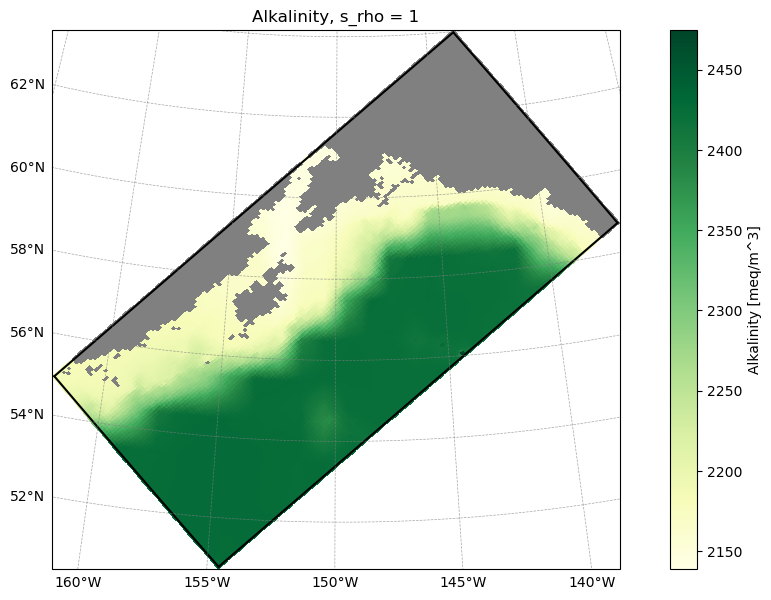

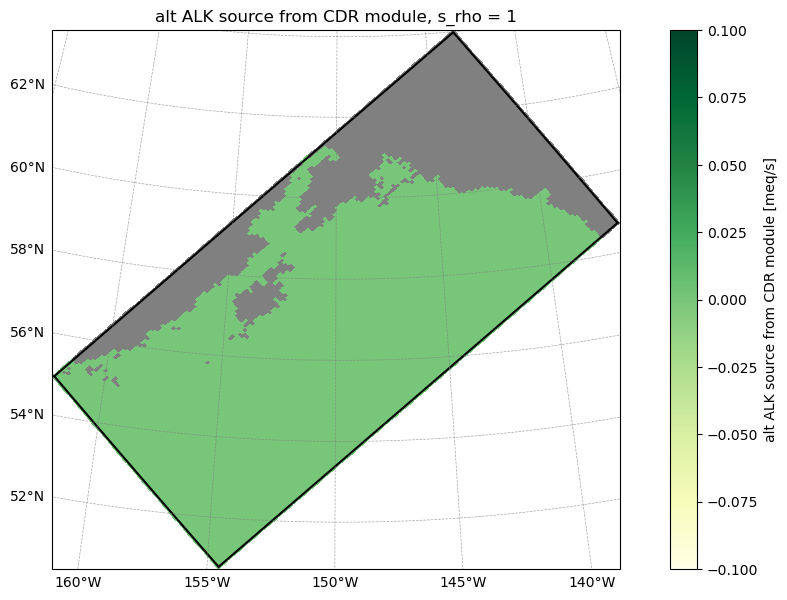

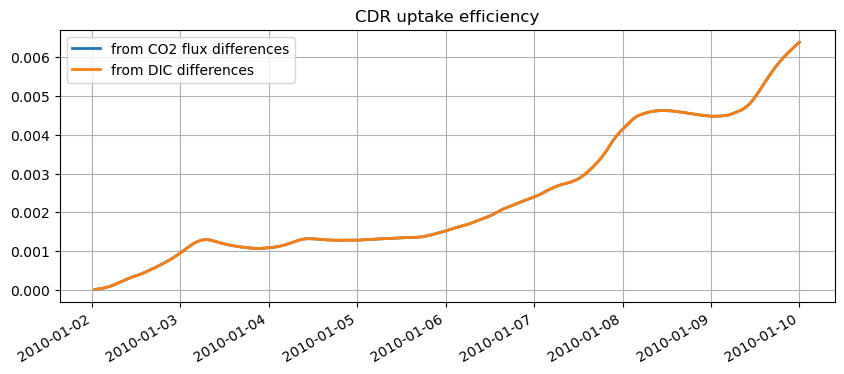

In [22]:
import pandas as pd
#import os,glob

run = "/Users/blsaenz/cson-forge-data/cson-forge-run/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs_20100101-20100110"

#grid = Grid.from_file(os.path.join(run,"input","input_datasets","cson_roms-marbl_v0_1_Gulf_of_Alaska_8procs_grid.nc"))
roms_output = rt.ROMSOutput(grid=ocn.grid, path=ocn.run_output_dir / "joined_output" / "output_cdr.*.nc", use_dask=True)

time_index = pd.DatetimeIndex(roms_output.ds.time.values)
print('First, Last output times: ',time_index[0],time_index[-1])
roms_output.plot("ALK", time=9, s=1)
roms_output.plot("ALK_ALT_source", time=4, s=1)
#roms_output.cdr_metrics()